Running benchmarks... (N=2500 may take a few seconds)
Finished testing N=100
Finished testing N=500
Finished testing N=2500


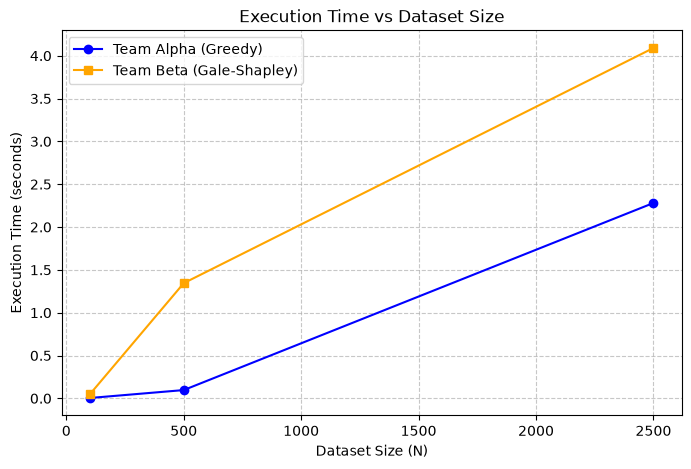

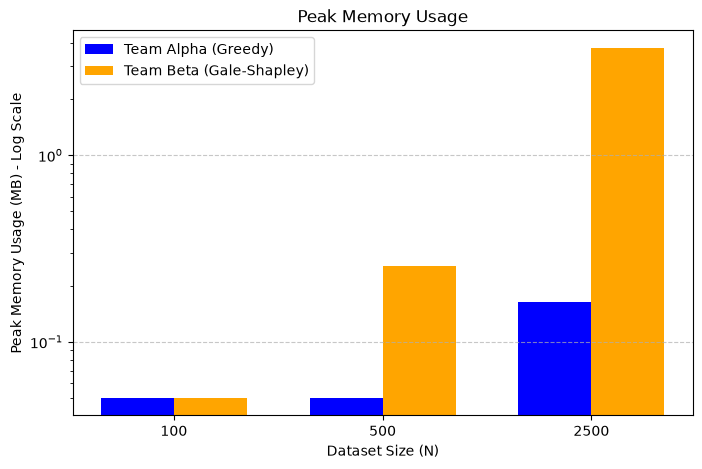

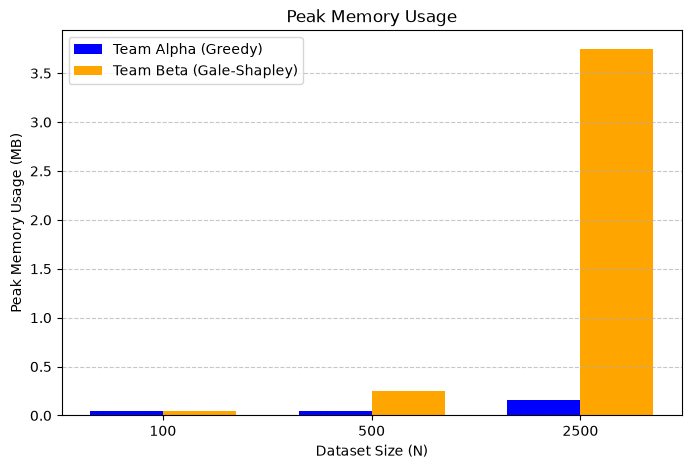

All graphs successfully generated and saved!


In [2]:
import pandas as pd
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np
import gc


def greedy_matching(apps, jobs):
    matches = []
    jobs_avail = {j['Job_ID']: j for j in jobs}
    
    for app in apps:
        for job_id in list(jobs_avail.keys()):
            if job_id in jobs_avail:
                job = jobs_avail[job_id]
                if (app['Skill_Level'] >= job['Required_Skill_Level'] and 
                    app['Years_Experience'] >= job['Required_Experience'] and 
                    job['Salary_Offer'] >= app['Expected_Salary']):
                    matches.append((app['Applicant_ID'], job['Job_ID']))
                    del jobs_avail[job_id] # Mark job as taken
                    break
    return matches

def gale_shapley(apps, jobs):
    app_prefs = {}
    for app in apps:
        valid = [j for j in jobs if (app['Skill_Level'] >= j['Required_Skill_Level'] and 
                                     app['Years_Experience'] >= j['Required_Experience'] and 
                                     j['Salary_Offer'] >= app['Expected_Salary'])]
        valid.sort(key=lambda x: x['Salary_Offer'], reverse=True)
        app_prefs[app['Applicant_ID']] = [j['Job_ID'] for j in valid]
        
    job_rankings = {}
    for job in jobs:
        valid = [a for a in apps if (a['Skill_Level'] >= job['Required_Skill_Level'] and 
                                     a['Years_Experience'] >= job['Required_Experience'] and 
                                     job['Salary_Offer'] >= a['Expected_Salary'])]
        valid.sort(key=lambda x: (x['Skill_Level'] + x['Years_Experience']), reverse=True)
        job_rankings[job['Job_ID']] = {a['Applicant_ID']: rank for rank, a in enumerate(valid)}
        
    free_apps = list(app_prefs.keys())
    app_next = {a: 0 for a in free_apps}
    job_match = {}
    
    while free_apps:
        a = free_apps.pop(0)
        prefs = app_prefs[a]
        if app_next[a] < len(prefs):
            j = prefs[app_next[a]]
            app_next[a] += 1
            
            if j not in job_match:
                job_match[j] = a
            else:
                curr_a = job_match[j]
                if a in job_rankings[j] and job_rankings[j][a] < job_rankings[j].get(curr_a, float('inf')):
                    job_match[j] = a
                    free_apps.append(curr_a) 
                else:
                    free_apps.append(a) 
    return list(job_match.items())


ns = [100, 500, 2500]
greedy_t, greedy_m = [], []
gs_t, gs_m = [], []

print("Running benchmarks... (N=2500 may take a few seconds)")

for n in ns:
    # Load the datasets
    df_a = pd.read_csv(f'applicants_N{n}.csv')
    df_j = pd.read_csv(f'jobs_N{n}.csv')
    apps = df_a.to_dict('records')
    jobs = df_j.to_dict('records')
    
    gc.collect() 
    tracemalloc.start()
    start = time.time()
    
    greedy_matching(apps, jobs)
    
    greedy_t.append(time.time() - start)
    _, peak = tracemalloc.get_traced_memory()
    greedy_m.append(max(peak / 1048576, 0.05)) 
    tracemalloc.stop()
    
    gc.collect()
    tracemalloc.start()
    start = time.time()
    
    gale_shapley(apps, jobs)
    
    gs_t.append(time.time() - start)
    _, peak = tracemalloc.get_traced_memory()
    gs_m.append(max(peak / 1048576, 0.05))
    tracemalloc.stop()
    
    print(f"Finished testing N={n}")


x = np.arange(len(ns))
width = 0.35

# --- GRAPH 1: Execution Time (Line Graph) ---
plt.figure(figsize=(8, 5))
plt.plot(ns, greedy_t, marker='o', linestyle='-', color='blue', label='Team Alpha (Greedy)')
plt.plot(ns, gs_t, marker='s', linestyle='-', color='orange', label='Team Beta (Gale-Shapley)')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time vs Dataset Size')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('actual_execution_time.png', bbox_inches='tight')
plt.show()

# --- GRAPH 2: Peak Memory Usage (Bar Graph - LOG SCALE) ---
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, greedy_m, width, color='blue', label='Team Alpha (Greedy)')
plt.bar(x + width/2, gs_m, width, color='orange', label='Team Beta (Gale-Shapley)')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Peak Memory Usage (MB) - Log Scale')
plt.title('Peak Memory Usage') 
plt.xticks(x, ns)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log') 
plt.savefig('actual_peak_memory_log.png', bbox_inches='tight')
plt.show()

# --- GRAPH 3: Peak Memory Usage (Bar Graph - LINEAR SCALE) ---
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, greedy_m, width, color='blue', label='Team Alpha (Greedy)')
plt.bar(x + width/2, gs_m, width, color='orange', label='Team Beta (Gale-Shapley)')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Peak Memory Usage (MB)')
plt.title('Peak Memory Usage') 
plt.xticks(x, ns)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('actual_peak_memory_linear.png', bbox_inches='tight')
plt.show()

print("All graphs successfully generated and saved!")